NYC Crime Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import matplotlib.ticker as mticker

In [51]:
# LOAD THE DATA
crime = pd.read_csv("NYPD_Arrest_Data_YTD.csv")
print("Shape:", crime.shape)
print("Columns:\n", crime.columns)
print("\nMissing values:\n", crime.isnull().sum())

Shape: (69305, 19)
Columns:
 Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

Missing values:
 ARREST_KEY             0
ARREST_DATE            0
PD_CD                  2
PD_DESC                0
KY_CD                 12
OFNS_DESC              0
LAW_CODE               0
LAW_CAT_CD           267
ARREST_BORO            0
ARREST_PRECINCT        0
JURISDICTION_CODE      0
AGE_GROUP              0
PERP_SEX               0
PERP_RACE              0
X_COORD_CD             0
Y_COORD_CD             0
Latitude               0
Longitude              0
Location               0
dtype: int64


In [53]:
# BASIC CLEANING
# Convert arrest date to datetime
crime["ARREST_DATE"] = pd.to_datetime(
    crime["ARREST_DATE"])

# Extract time features
crime["year"] = crime["ARREST_DATE"].dt.year
crime["month"] = crime["ARREST_DATE"].dt.month
crime["day"] = crime["ARREST_DATE"].dt.day
crime["day_of_week"] = crime["ARREST_DATE"].dt.day_name()
crime["weekend"] = crime["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Replace literal '(null)' strings with true NaN
crime = crime.replace("(null)", np.nan)

# Remove duplicate rows if any
crime = crime.drop_duplicates()

# Ensure precinct is numeric
crime["ARREST_PRECINCT"] = pd.to_numeric(
    crime["ARREST_PRECINCT"])

# Encode categorical variables
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(crime[["LAW_CAT_CD", "ARREST_BORO"]])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(["LAW_CAT_CD", "ARREST_BORO"]))
crime = pd.concat([crime.reset_index(drop=True), encoded_df], axis=1)

print("\nCleaned Shape:", crime.shape)


Cleaned Shape: (69305, 35)


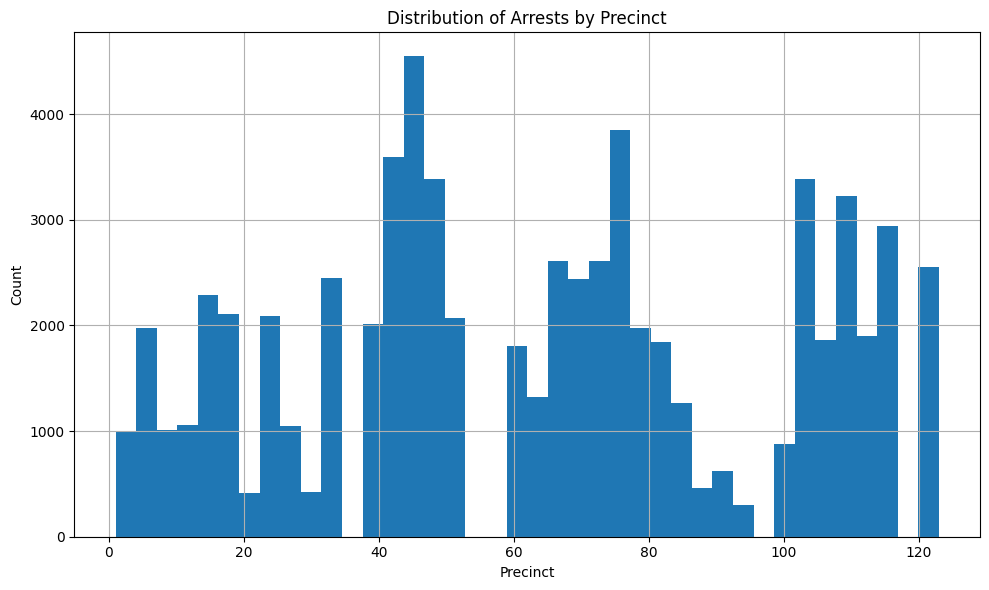

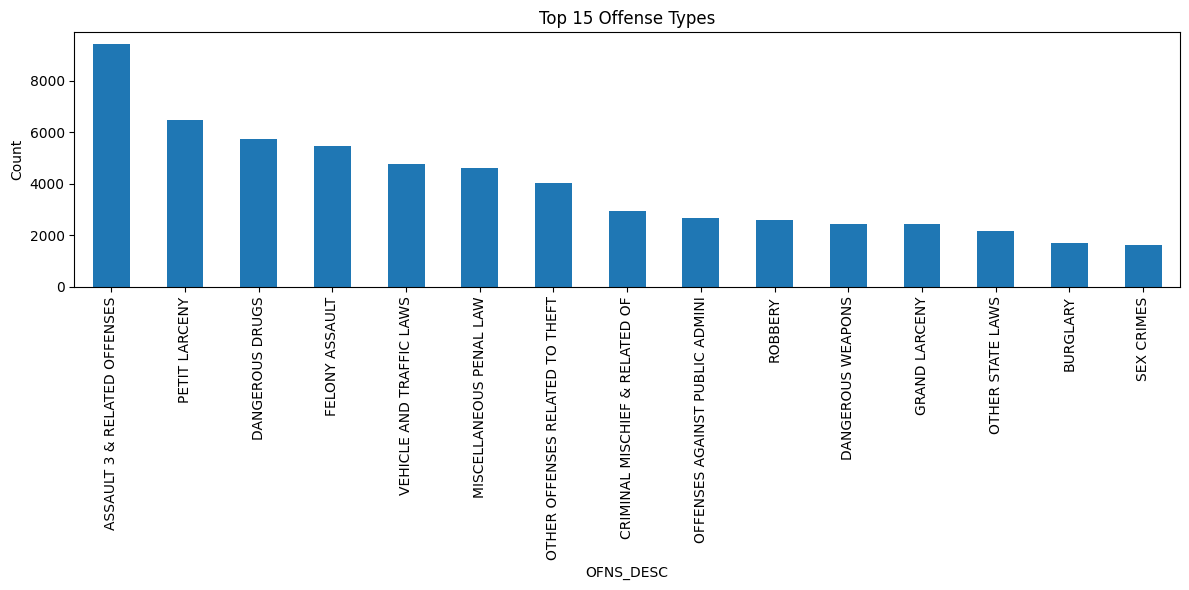

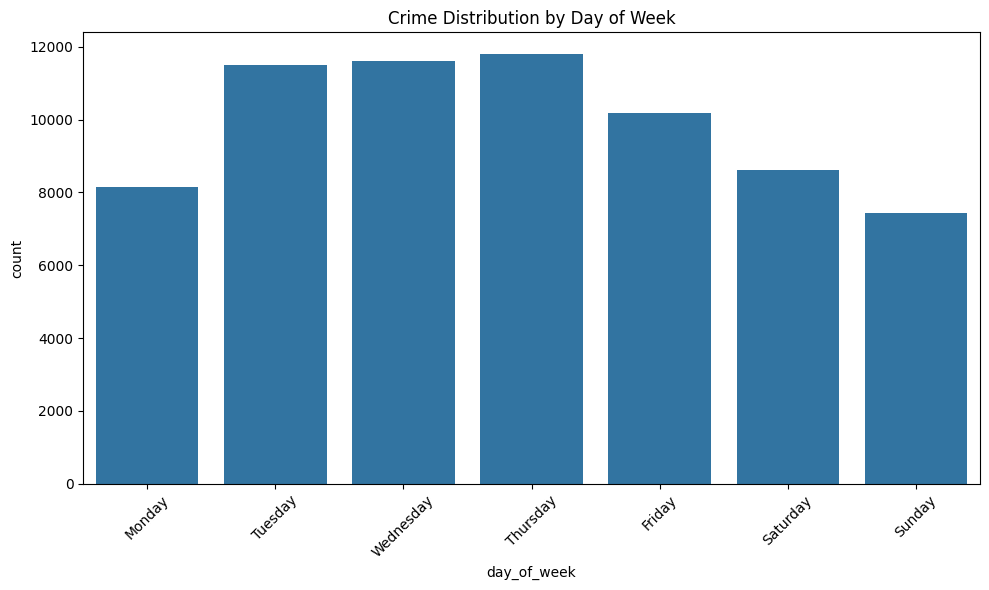

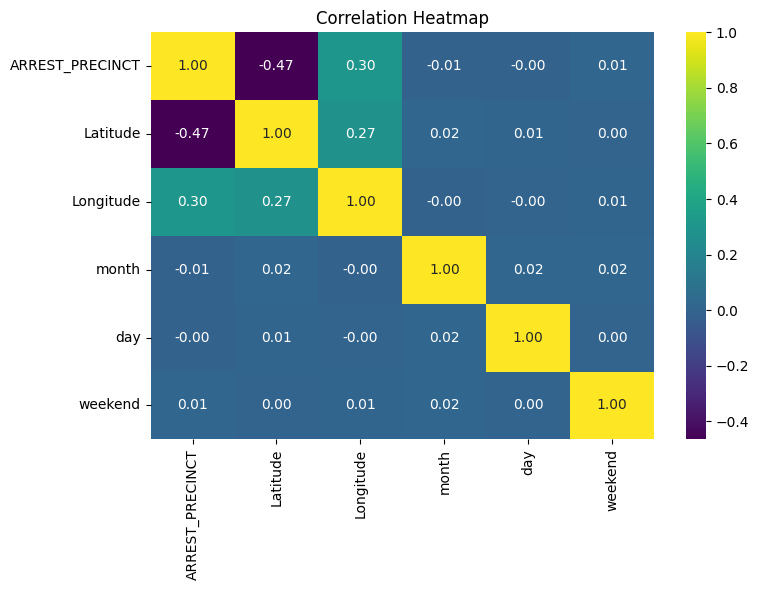

In [7]:
# EXPLORATORY DATA ANALYSIS
# Histogram: arrests by precinct
plt.figure(figsize=(10, 6))
crime["ARREST_PRECINCT"].hist(bins=40)
plt.title("Distribution of Arrests by Precinct")
plt.xlabel("Precinct")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Proportional distribution of offense type
plt.figure(figsize=(12, 6))
crime["OFNS_DESC"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Offense Types")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Distribution by day of week
order = ["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 6))
sns.countplot(data=crime, x="day_of_week", order=order)
plt.title("Crime Distribution by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_cols = ["ARREST_PRECINCT", "Latitude", "Longitude", "month", "day", "weekend"]

plt.figure(figsize=(8, 6))
sns.heatmap(crime[numeric_cols].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# Save to a new CSV for your team
crime.to_csv('NYPD_Data.csv', index=False)

NYC Deployment Data

In [37]:
deployment = pd.read_excel("NYC_deployment.xlsx")
deployment = deployment.dropna(subset=['Bureau'])
deployment['Year'] = 2025
deployment['Command'] = deployment['Command'].astype(str).str.strip()
deployment['Viper'] = deployment['Command'].str.contains(r'\*', na=False)
deployment['Command'] = deployment['Command'].str.replace('*', '', regex=False).str.strip()

def format_command(cmd):
    try:
        return str(int(float(cmd))).zfill(3)
    except:
        return cmd

deployment['Command'] = deployment['Command'].apply(format_command)

print(deployment.head(10).to_string())

  Command  Total  % of Command Bureau  Year  Viper
0     001      4           2.7   PBMS  2025  False
1     005      1           0.9   PBMS  2025  False
2     006      4           3.1   PBMS  2025  False
3     007      0           0.0   PBMS  2025  False
4     009      1           0.7   PBMS  2025  False
5     010      2           1.8   PBMS  2025  False
6     013      2           1.4   PBMS  2025  False
7     014      4           1.8   PBMS  2025  False
8     017      2           1.7   PBMS  2025  False
9     018      2           1.0   PBMS  2025  False


In [41]:
#Check
print(deployment['Command'].unique())
print(deployment[deployment['Viper'] == True][['Command', 'Bureau']])
print(deployment.groupby('Bureau')['% of Command'].agg(['mean', 'max', 'min']).round(2))
print("Shape:", deployment.shape)

['001' '005' '006' '007' '009' '010' '013' '014' '017' '018'
 'Central Park' '019' '020' '023' '024' '025' '026' '028' '030' '032'
 '033' '034' '040' '041' '042' '043' '044' '045' '046' '047' '048' '049'
 '050' '052' '060' '061' '062' '063' '066' '067' '068' '069' '070' '071'
 '072' '076' '078' '073' '075' '077' '079' '081' '083' '084' '088' '090'
 '094' '100' '101' '102' '103' '105' '106' '107' '113' '116' '104' '108'
 '109' '110' '111' '112' '114' '115' '120' '121' '122' '123' 'PSA 1'
 'PSA 2' 'PSA 3' 'PSA 4' 'PSA 5' 'PSA 6' 'PSA 7' 'PSA 8' 'PSA 9' 'TD 1'
 'TD 2' 'TD 3' 'TD 4' 'TD 11' 'TD 12' 'TD 20' 'TD 23' 'TD 30' 'TD 32'
 'TD 33' 'TD 34']
   Command   Bureau
81     120     PBSI
86   PSA 1  Housing
87   PSA 2  Housing
89   PSA 4  Housing
90   PSA 5  Housing
91   PSA 6  Housing
92   PSA 7  Housing
93   PSA 8  Housing
94   PSA 9  Housing
         mean  max  min
Bureau                 
Housing  3.53  7.9  1.1
PBBN     3.92  6.1  1.3
PBBS     3.79  9.0  0.7
PBBX     4.18  7.7  0.7
PBMN

/var/folders/3b/x6bd51lx7dngr1dp8lkc5dc80000gn/T/ipykernel_78680/397218367.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_by_bureau, labels=bureau_order, patch_artist=True,


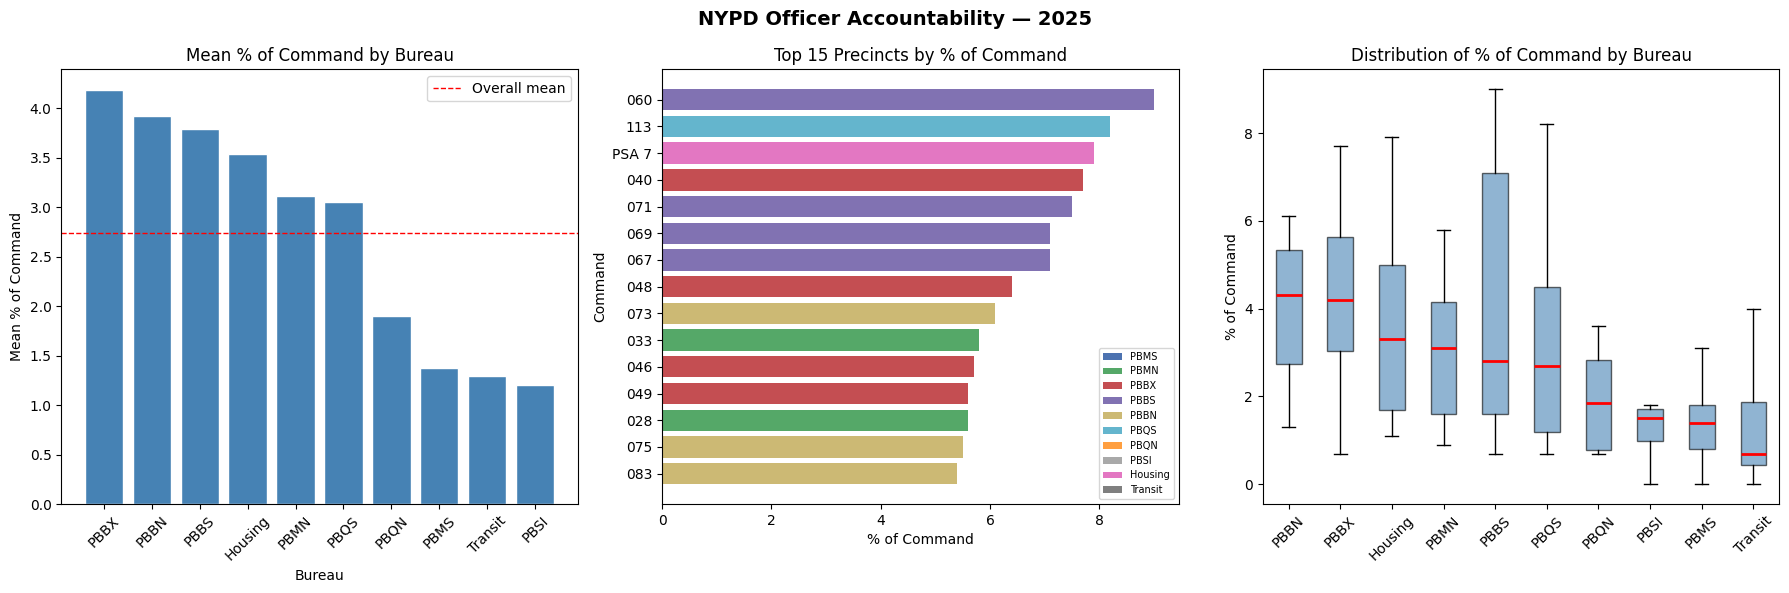

In [45]:
#EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# bar chart: mean % by bureau
bureau_means = deployment.groupby('Bureau')['% of Command'].mean().sort_values(ascending=False)
axes[0].bar(bureau_means.index, bureau_means.values, color='steelblue', edgecolor='white')
axes[0].set_title('Mean % of Command by Bureau')
axes[0].set_xlabel('Bureau')
axes[0].set_ylabel('Mean % of Command')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(bureau_means.mean(), color='red', linestyle='--', linewidth=1, label='Overall mean')
axes[0].legend()

#horizontal bar: top 15 precincts by %
top15 = deployment.nlargest(15, '% of Command').sort_values('% of Command')
colors = top15['Bureau'].map({
    'PBMS': '#4C72B0', 'PBMN': '#55A868', 'PBBX': '#C44E52',
    'PBBS': '#8172B2', 'PBBN': '#CCB974', 'PBQS': '#64B5CD',
    'PBQN': '#FF9F40', 'PBSI': '#A9A9A9', 'Housing': '#E377C2', 'Transit': '#7F7F7F'
})
axes[1].barh(top15['Command'], top15['% of Command'], color=colors)
axes[1].set_title('Top 15 Precincts by % of Command')
axes[1].set_xlabel('% of Command')
axes[1].set_ylabel('Command')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in {
    'PBMS': '#4C72B0', 'PBMN': '#55A868', 'PBBX': '#C44E52',
    'PBBS': '#8172B2', 'PBBN': '#CCB974', 'PBQS': '#64B5CD',
    'PBQN': '#FF9F40', 'PBSI': '#A9A9A9', 'Housing': '#E377C2', 'Transit': '#7F7F7F'
}.items()]
axes[1].legend(handles=legend_elements, fontsize=7, loc='lower right')

#box plot: distribution of % by bureau
bureau_order = deployment.groupby('Bureau')['% of Command'].median().sort_values(ascending=False).index
data_by_bureau = [deployment[deployment['Bureau'] == b]['% of Command'].values for b in bureau_order]
axes[2].boxplot(data_by_bureau, labels=bureau_order, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Distribution of % of Command by Bureau')
axes[2].set_ylabel('% of Command')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('NYPD Officer Accountability — 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nypd_overview.png', bbox_inches='tight', dpi=150)
plt.show()

In [47]:
deployment.to_csv('nypd_deployment_2025.csv', index=False)

Merge Data sets

In [65]:
#merge deployment into crime df
deployment.loc[deployment['Command'] == 'Central Park', 'ARREST_PRECINCT'] = 22

# re-merge
merged = crime.merge(
    deployment[['ARREST_PRECINCT', 'Total', '% of Command', 'Bureau', 'Viper']],
    on='ARREST_PRECINCT',
    how='left'
)
print("Unmatched:", merged[merged['Bureau'].isna()]['ARREST_PRECINCT'].unique())
merged.shape

Unmatched: []


(69305, 39)

In [67]:
print("Columns:\n", merged.columns)
print("\nMissing values:\n", merged.isnull().sum())

Columns:
 Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location', 'year', 'month',
       'day', 'day_of_week', 'weekend', 'LAW_CAT_CD_9', 'LAW_CAT_CD_F',
       'LAW_CAT_CD_I', 'LAW_CAT_CD_M', 'LAW_CAT_CD_V', 'LAW_CAT_CD_nan',
       'ARREST_BORO_B', 'ARREST_BORO_K', 'ARREST_BORO_M', 'ARREST_BORO_Q',
       'ARREST_BORO_S', 'Total', '% of Command', 'Bureau', 'Viper'],
      dtype='object')

Missing values:
 ARREST_KEY               0
ARREST_DATE              0
PD_CD                    2
PD_DESC                 12
KY_CD                   12
OFNS_DESC               12
LAW_CODE                 2
LAW_CAT_CD             269
ARREST_BORO              0
ARREST_PRECINCT          0
JURISDICTION_CODE        0
AGE_GROUP            16933
PERP_SEX             16933
PERP_RACE 

/var/folders/3b/x6bd51lx7dngr1dp8lkc5dc80000gn/T/ipykernel_78680/1435743368.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax8.boxplot(bucket_data, labels=['0-2%', '2-4%', '4-6%', '6-10%'], patch_artist=True,


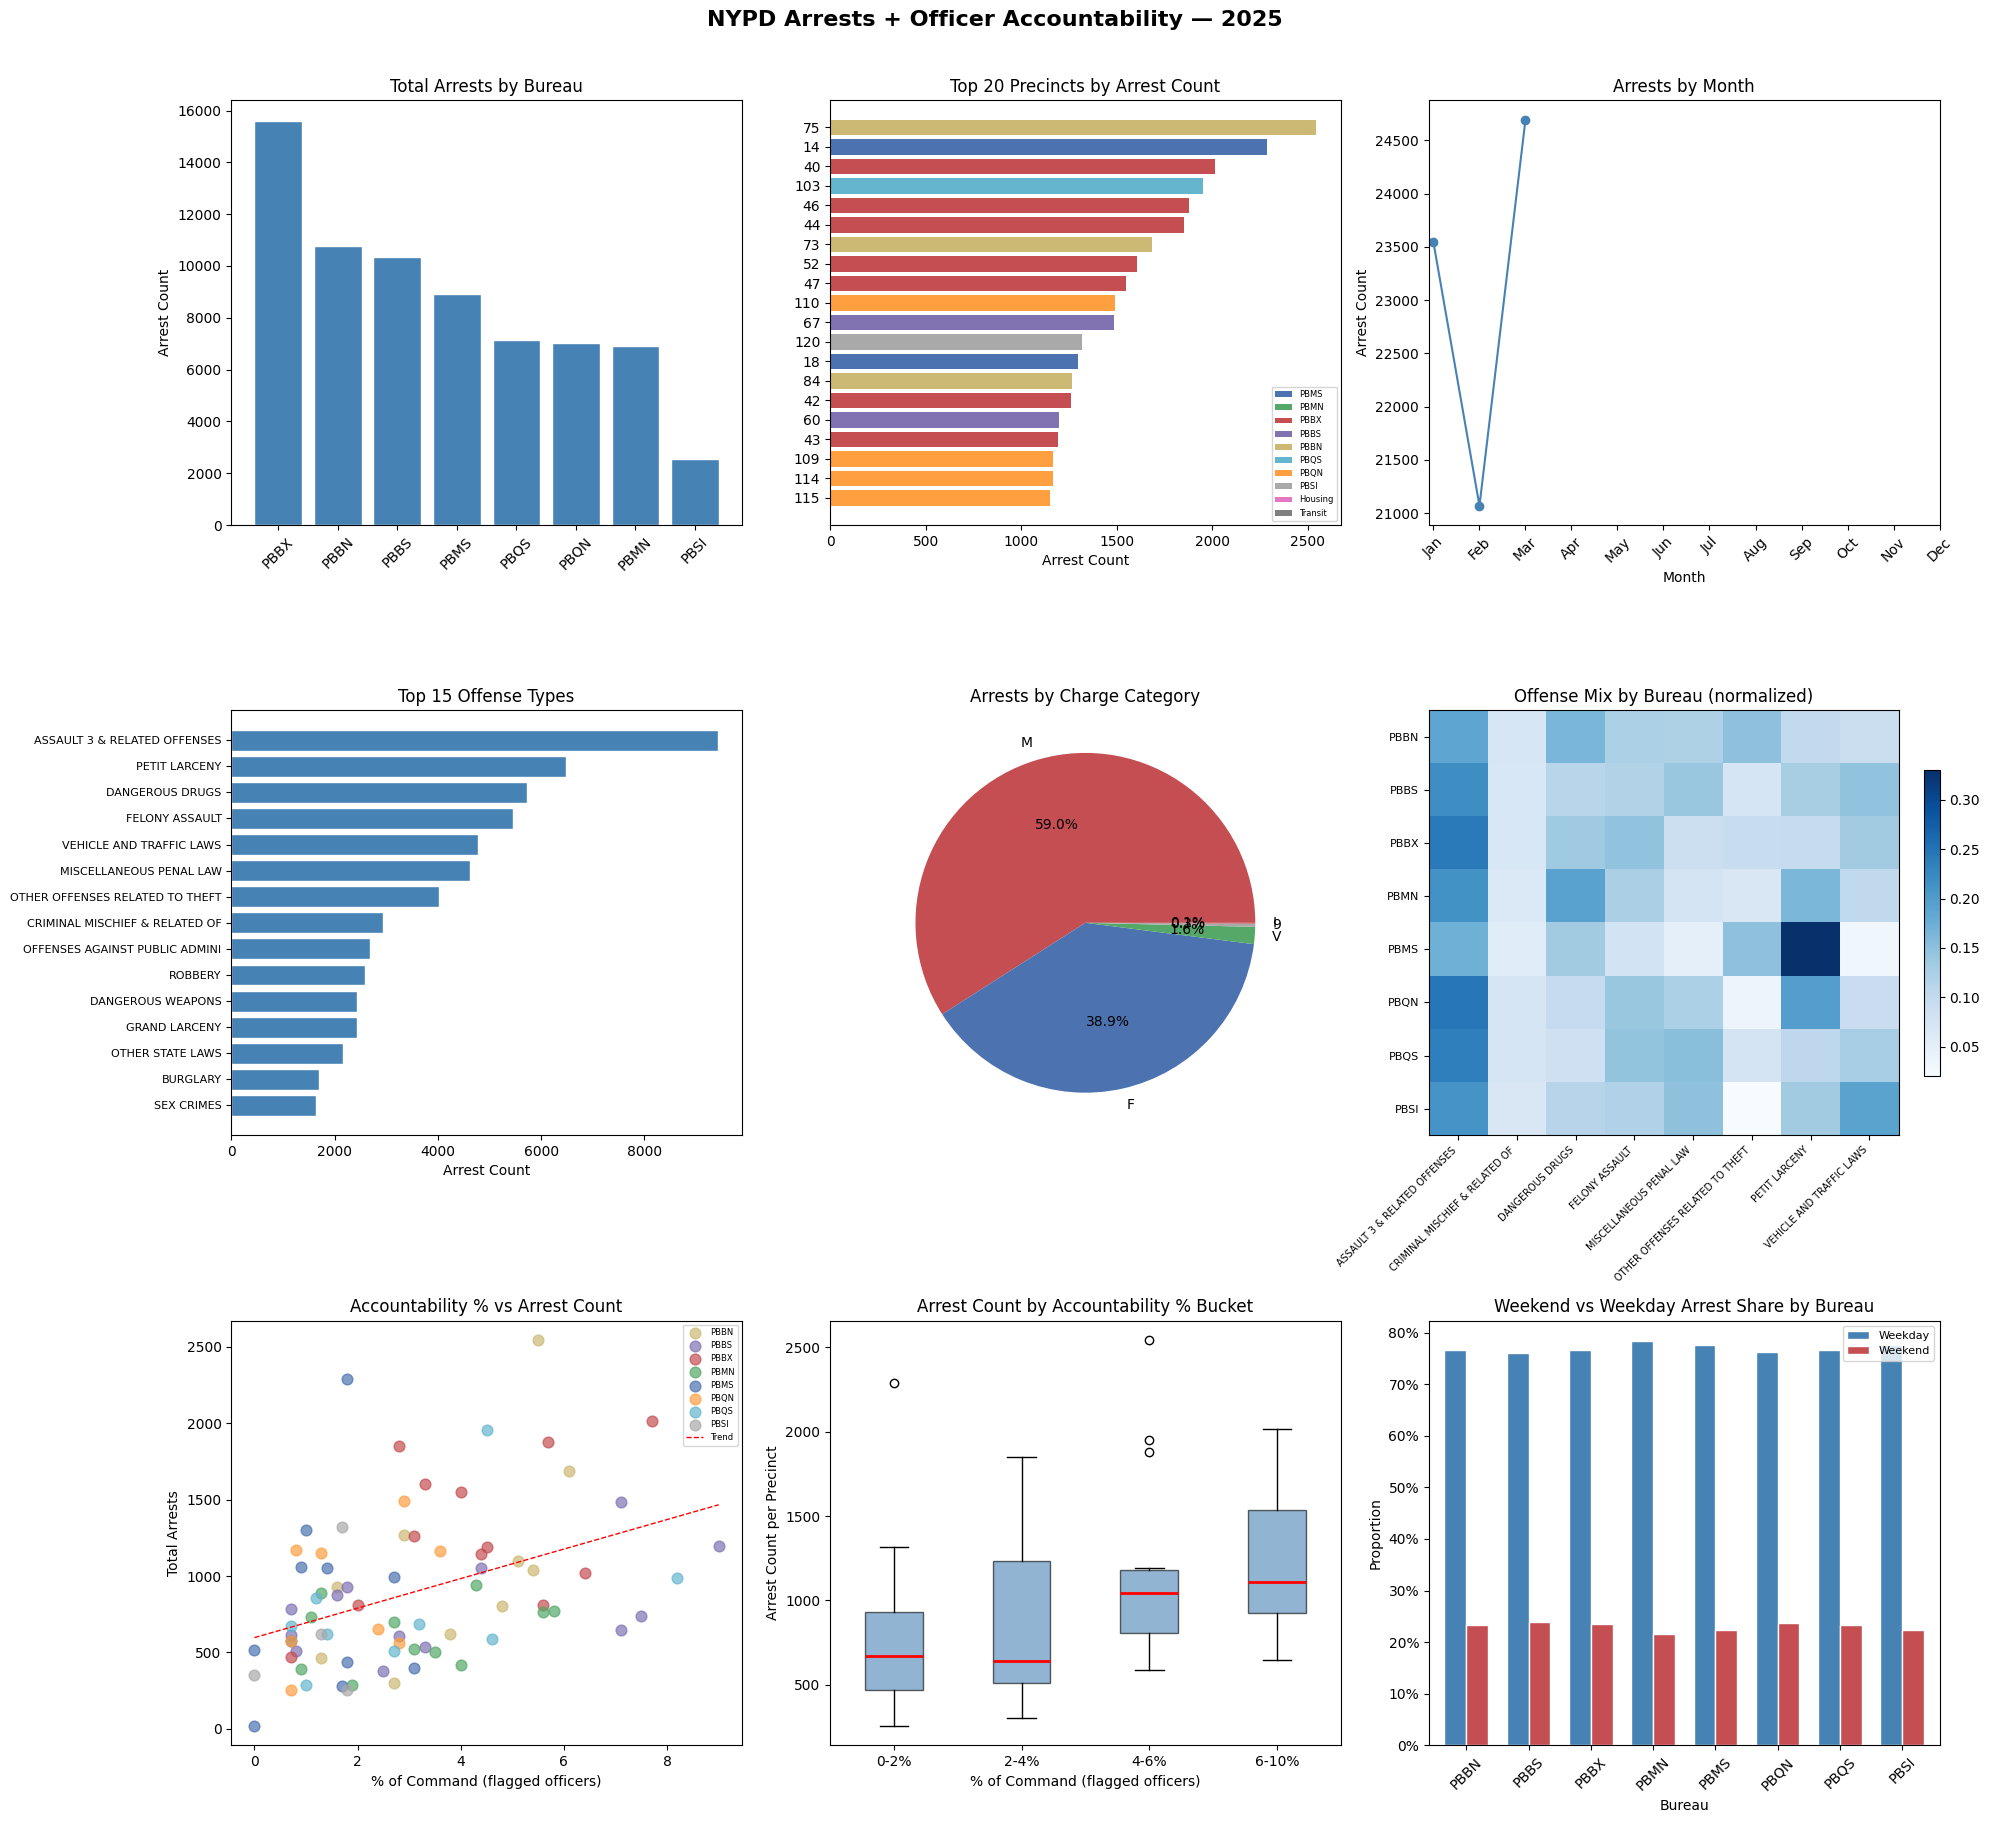

In [75]:
#EDA
fig = plt.figure(figsize=(20, 18))

#total arrests by bureau
ax1 = fig.add_subplot(3, 3, 1)
arrests_by_bureau = merged.groupby('Bureau')['ARREST_KEY'].count().sort_values(ascending=False)
ax1.bar(arrests_by_bureau.index, arrests_by_bureau.values, color='steelblue', edgecolor='white')
ax1.set_title('Total Arrests by Bureau')
ax1.set_ylabel('Arrest Count')
ax1.tick_params(axis='x', rotation=45)

# arrests per precincts
ax2 = fig.add_subplot(3, 3, 2)
arrests_by_precinct = merged.groupby(['ARREST_PRECINCT', 'Bureau'])['ARREST_KEY'].count().reset_index()
top20 = arrests_by_precinct.nlargest(20, 'ARREST_KEY').sort_values('ARREST_KEY')
bureau_colors = {
    'PBMS': '#4C72B0', 'PBMN': '#55A868', 'PBBX': '#C44E52',
    'PBBS': '#8172B2', 'PBBN': '#CCB974', 'PBQS': '#64B5CD',
    'PBQN': '#FF9F40', 'PBSI': '#A9A9A9', 'Housing': '#E377C2', 'Transit': '#7F7F7F'
}
colors = top20['Bureau'].map(bureau_colors)
ax2.barh(top20['ARREST_PRECINCT'].astype(str), top20['ARREST_KEY'], color=colors)
ax2.set_title('Top 20 Precincts by Arrest Count')
ax2.set_xlabel('Arrest Count')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in bureau_colors.items()]
ax2.legend(handles=legend_elements, fontsize=6, loc='lower right')

# arrests by month
ax3 = fig.add_subplot(3, 3, 3)
arrests_by_month = merged.groupby('month')['ARREST_KEY'].count()
ax3.plot(arrests_by_month.index, arrests_by_month.values, marker='o', color='steelblue')
ax3.set_title('Arrests by Month')
ax3.set_ylabel('Arrest Count')
ax3.set_xlabel('Month')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

# top 15 offense types
ax4 = fig.add_subplot(3, 3, 4)
top_offenses = merged['OFNS_DESC'].value_counts().head(15).sort_values()
ax4.barh(top_offenses.index, top_offenses.values, color='steelblue', edgecolor='white')
ax4.set_title('Top 15 Offense Types')
ax4.set_xlabel('Arrest Count')
ax4.tick_params(axis='y', labelsize=8)

#felony vs misdemeanor vs violation
ax5 = fig.add_subplot(3, 3, 5)
law_cat = merged['LAW_CAT_CD'].value_counts()
ax5.pie(law_cat.values, labels=law_cat.index, autopct='%1.1f%%',
        colors=['#C44E52', '#4C72B0', '#55A868', '#A9A9A9'])
ax5.set_title('Arrests by Charge Category')

#offense type by bureau (heatmap)
ax6 = fig.add_subplot(3, 3, 6)
top8_offenses = merged['OFNS_DESC'].value_counts().head(8).index
heatmap_data = merged[merged['OFNS_DESC'].isin(top8_offenses)].groupby(
    ['Bureau', 'OFNS_DESC'])['ARREST_KEY'].count().unstack(fill_value=0)
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
im = ax6.imshow(heatmap_norm.values, aspect='auto', cmap='Blues')
ax6.set_xticks(range(len(heatmap_norm.columns)))
ax6.set_xticklabels(heatmap_norm.columns, rotation=45, ha='right', fontsize=7)
ax6.set_yticks(range(len(heatmap_norm.index)))
ax6.set_yticklabels(heatmap_norm.index, fontsize=8)
ax6.set_title('Offense Mix by Bureau (normalized)')
plt.colorbar(im, ax=ax6, fraction=0.03)

#scatter: accountability % vs arrest count per precinct
ax7 = fig.add_subplot(3, 3, 7)
precinct_stats = merged.groupby(['ARREST_PRECINCT', '% of Command', 'Bureau']).agg(
    arrest_count=('ARREST_KEY', 'count')).reset_index()
for bureau, group in precinct_stats.groupby('Bureau'):
    ax7.scatter(group['% of Command'], group['arrest_count'],
                label=bureau, color=bureau_colors.get(bureau, 'gray'), alpha=0.7, s=60)
m, b = np.polyfit(precinct_stats['% of Command'], precinct_stats['arrest_count'], 1)
x_line = np.linspace(precinct_stats['% of Command'].min(), precinct_stats['% of Command'].max(), 100)
ax7.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=1, label='Trend')
ax7.set_title('Accountability % vs Arrest Count')
ax7.set_xlabel('% of Command (flagged officers)')
ax7.set_ylabel('Total Arrests')
ax7.legend(fontsize=6)

# box plot: arrest count distribution by accountability % bucket
ax8 = fig.add_subplot(3, 3, 8)
precinct_stats['pct_bucket'] = pd.cut(precinct_stats['% of Command'],
    bins=[0, 2, 4, 6, 10], labels=['0-2%', '2-4%', '4-6%', '6-10%'])
bucket_data = [precinct_stats[precinct_stats['pct_bucket'] == b]['arrest_count'].values
               for b in ['0-2%', '2-4%', '4-6%', '6-10%']]
ax8.boxplot(bucket_data, labels=['0-2%', '2-4%', '4-6%', '6-10%'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))
ax8.set_title('Arrest Count by Accountability % Bucket')
ax8.set_xlabel('% of Command (flagged officers)')
ax8.set_ylabel('Arrest Count per Precinct')

# weekend vs weekday arrests by bureau
ax9 = fig.add_subplot(3, 3, 9)
weekend_bureau = merged.groupby(['Bureau', 'weekend'])['ARREST_KEY'].count().unstack()
weekend_bureau.columns = ['Weekday', 'Weekend']
weekend_bureau_pct = weekend_bureau.div(weekend_bureau.sum(axis=1), axis=0)
weekend_bureau_pct.plot(kind='bar', ax=ax9, color=['steelblue', '#C44E52'],
                        edgecolor='white', width=0.7)
ax9.set_title('Weekend vs Weekday Arrest Share by Bureau')
ax9.set_ylabel('Proportion')
ax9.tick_params(axis='x', rotation=45)
ax9.legend(['Weekday', 'Weekend'], fontsize=8)
ax9.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('NYPD Arrests + Officer Accountability — 2025', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nypd_merged_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [77]:
merged.to_csv('nypd_merged_2025.csv', index=False)